# Right-Censored Density Estimation with HAL

This notebook uses the updated Stage-2 API:

- `do_over_smooth=False`: Stage 2A (direct EM from Stage 1, no oversmooth grid/CV)
- `do_over_smooth=True`: Stage 2B (oversmooth grid + EM)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haldensity.censoring import (
    RightCensoredInitTuner,
    RightCensoredEMTuner,
    incomplete_loglik,
    kl_divergence,
)
from haldensity.utils import TruncatedGMM


/Users/zzp/Desktop/Github/HAL_Projects/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1) Generate synthetic right-censored data
np.random.seed(42)
n = 300

sampler_params = {
    'components': [
        {'mean': 0.2, 'std': 0.05, 'lower': 0, 'upper': 1},
        {'mean': 0.5, 'std': 0.05, 'lower': 0, 'upper': 1},
        {'mean': 0.8, 'std': 0.05, 'lower': 0, 'upper': 1},
    ],
    'weights': [0.33, 0.34, 0.33],
}
sampler = TruncatedGMM(**sampler_params)
t_event = sampler.generate_samples(n)
t_cens = np.random.uniform(0, 1, size=n)
T = np.minimum(t_event, t_cens)
Delta = (t_event <= t_cens).astype(int)
data = pd.DataFrame({'T': T, 'Delta': Delta})

print(f'n={n}, uncensored={Delta.sum()}, censored={n-Delta.sum()}')
print(f'Censoring rate: {1 - Delta.mean():.1%}')
data.head()


n=300, uncensored=153, censored=147
Censoring rate: 49.0%


,T,Delta
0,0.380891,0
1,0.776182,1
2,0.464304,1
3,0.806121,1
4,0.175453,1


In [3]:
# 2) Stage 1 (Init): IPCW HAL-MLE tuned by CV
init_tuner = RightCensoredInitTuner(
    data=data,
    cv_folds=5,
    n_grid_points=100,
    silent=True,
)
init_tuner.param_overrides = {'basis_order': [2]}
init_result = init_tuner.optimize(n_trials=20)

print('Stage 1 (Init):')
print('  best_params:', init_result.best_params)
print('  n_selected_knots:', int(init_result.estimator.get_results()['n_selected_knots']))


Stage 1 (Init):
  best_params: {'norm_constraint': 984.4498380225954, 'basis_order': 2}
  n_selected_knots: 44


In [4]:
# 3A) Stage 2A: no oversmooth (direct EM from Stage 1)
em_result_no_oversmooth = RightCensoredEMTuner(
    data,
    stage1_estimator=init_result.estimator,
    do_over_smooth=False,
    em_m_imputations=50,
    em_max_em_iter=20,
    em_tol=1e-3,
    em_norm_factor=1.0,
    n_grid_points=100,
    random_state=42,
    silent=True,
).optimize()

print('Stage 2A (no oversmooth):')
print('  best_params:', em_result_no_oversmooth.best_params)
print('  mode:', em_result_no_oversmooth.metadata['mode'])


Stage 2A (no oversmooth):
  best_params: {'oversmooth_factor': 1.0, 'em_norm_factor': 1.0}
  mode: no_oversmooth


In [5]:
# 3B) Stage 2B: oversmooth grid + EM
em_result_oversmooth = RightCensoredEMTuner(
    data,
    stage1_estimator=init_result.estimator,
    do_over_smooth=True,
    oversmooth_factors=[0.6, 0.7, 0.8, 0.9, 1.0],
    em_m_imputations=50,
    em_max_em_iter=20,
    em_tol=1e-3,
    em_norm_factor=1.5,
    n_grid_points=100,
    random_state=42,
    silent=True,
).optimize()

print('Stage 2B (oversmooth):')
print('  best_params:', em_result_oversmooth.best_params)
print('  mode:', em_result_oversmooth.metadata['mode'])


Stage 2B (oversmooth):
  best_params: {'oversmooth_factor': 0.7, 'em_norm_factor': 1.5}
  mode: oversmooth


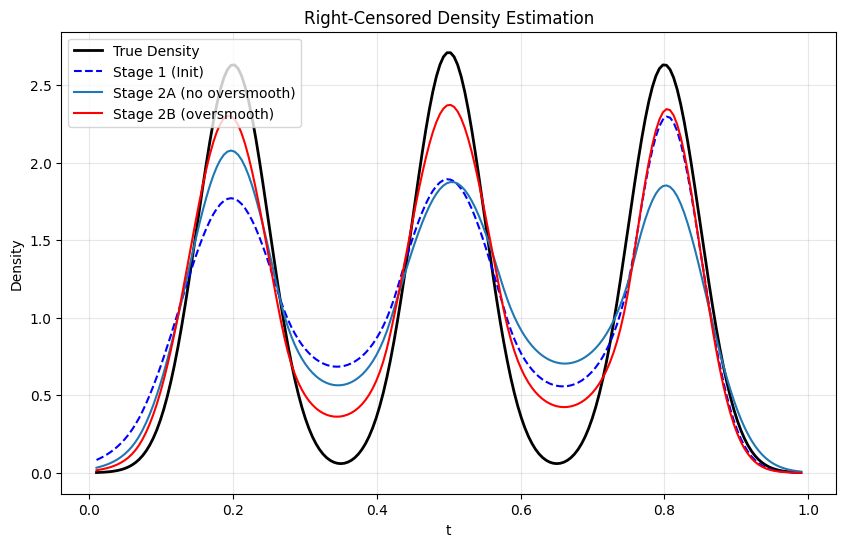

In [6]:
# 4) Compare densities
grid = np.linspace(0.01, 0.99, 200)
true_density = sampler.compute_density(grid)
init_density = init_result.estimator.get_density_at_points(grid)
stage2a_density = em_result_no_oversmooth.estimator.get_density_at_points(grid)
stage2b_density = em_result_oversmooth.estimator.get_density_at_points(grid)

plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', lw=2, label='True Density')
plt.plot(grid, init_density, 'b--', lw=1.5, label='Stage 1 (Init)')
plt.plot(grid, stage2a_density, color='tab:blue', lw=1.5, label='Stage 2A (no oversmooth)')
plt.plot(grid, stage2b_density, 'r-', lw=1.5, label='Stage 2B (oversmooth)')
plt.xlabel('t')
plt.ylabel('Density')
plt.title('Right-Censored Density Estimation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [7]:
# 5) Log-likelihood and KL diagnostics
ll_init = float(incomplete_loglik(init_result.estimator, data))
ll_2a = float(incomplete_loglik(em_result_no_oversmooth.estimator, data))
ll_2b = float(incomplete_loglik(em_result_oversmooth.estimator, data))

grid_kl = np.linspace(0.001, 0.999, 4000)
kl_init = float(kl_divergence(sampler.compute_density, grid_kl, init_result.estimator.get_density_at_points(grid_kl)))
kl_2a = float(kl_divergence(sampler.compute_density, grid_kl, em_result_no_oversmooth.estimator.get_density_at_points(grid_kl)))
kl_2b = float(kl_divergence(sampler.compute_density, grid_kl, em_result_oversmooth.estimator.get_density_at_points(grid_kl)))

print('Incomplete-data log-likelihood:')
print(f'  Stage 1:  {ll_init:.4f}')
print(f'  Stage 2A: {ll_2a:.4f}')
print(f'  Stage 2B: {ll_2b:.4f}')

print('KL(true || est):')
print(f'  Stage 1:  {kl_init:.6f}')
print(f'  Stage 2A: {kl_2a:.6f}')
print(f'  Stage 2B: {kl_2b:.6f}')

print('n_selected_knots:')
print('  Stage 1:', int(init_result.estimator.get_results()['n_selected_knots']))
print('  Stage 2A:', int(em_result_no_oversmooth.estimator.get_results()['n_selected_knots']))
print('  Stage 2B:', int(em_result_oversmooth.estimator.get_results()['n_selected_knots']))


Incomplete-data log-likelihood:
  Stage 1:  8.5185
  Stage 2A: 10.6743
  Stage 2B: 21.6087
KL(true || est):
  Stage 1:  0.107127
  Stage 2A: 0.104364
  Stage 2B: 0.043651
n_selected_knots:
  Stage 1: 44
  Stage 2A: 44
  Stage 2B: 18
